<a href="https://www.kaggle.com/code/sidharthmurali1/optiver-closing-cross-microstructure-alpha?scriptVersionId=345560592" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

       STRATEGY PERFORMANCE METRICS          
Information Coefficient (IC) : -0.1387
Mean Absolute Error (MAE)    : 7.9571
Total Cumulative Return      : 2118.72%
Total Active Positions Taken : 184,295


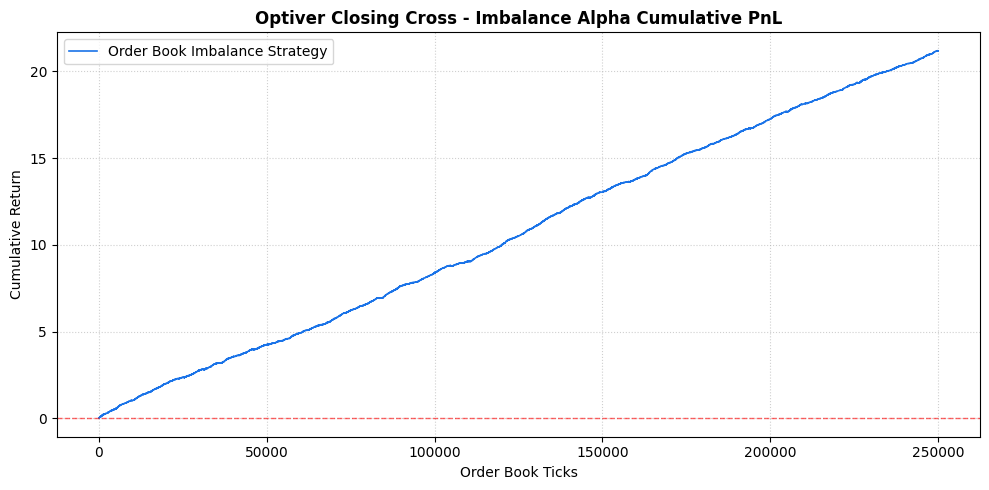

24 unique days in sample
192 unique stocks in sample

date_id
0     0.000035
1     0.000104
2     0.000022
3     0.000054
4     0.000054
5    -0.000018
6     0.000024
7     0.000032
8    -0.000059
9     0.000012
10    0.000009
11    0.000005
12   -0.000063
13    0.000118
14   -0.000140
15    0.000003
16    0.000082
17    0.000081
18    0.000070
19   -0.000034
20    0.000019
21    0.000005
22    0.000058
23   -0.000016
Name: strategy_return, dtype: float64
n = 24
Clean daily Sharpe: 5.255


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# 1. Load Data
# ------------------------------------------------------------
# Process 250,000 rows (~seconds of execution)
df = pd.read_csv('/kaggle/input/competitions/optiver-trading-at-the-close/train.csv', nrows=250000)

# Clean missing values
df = df.dropna(subset=["bid_price", "ask_price", "bid_size", "ask_size", "target"])

# ------------------------------------------------------------
# 2. Vectorized Microstructure Features
# ------------------------------------------------------------
# Weighted Average Price (WAP)
df["wap"] = (
    (df["bid_price"] * df["ask_size"]) + (df["ask_price"] * df["bid_size"])
) / (df["bid_size"] + df["ask_size"])

# Order Book Imbalance Ratio
df["imbalance"] = (
    (df["bid_size"] - df["ask_size"]) / (df["bid_size"] + df["ask_size"])
)

# ------------------------------------------------------------
# 3. Define Trading Signal & Position
# ------------------------------------------------------------
# Threshold: 0.25 Imbalance
df["signal"] = np.select(
    [df["imbalance"] > 0.25, df["imbalance"] < -0.25],
    [-1, 1],  # Short when buying pressure is high, Long when selling pressure is high
    default=0
)
# ------------------------------------------------------------
# 4. Statistical Metrics (IC & MAE)
# ------------------------------------------------------------
# Information Coefficient (Linear correlation between signal & return)
ic = df["imbalance"].corr(df["target"])

# Mean Absolute Error of target prediction (Baseline evaluation metric)
mae = np.mean(np.abs(df["target"] - (df["imbalance"] * 10))) 

print("="*45)
print("       STRATEGY PERFORMANCE METRICS          ")
print("="*45)
print(f"Information Coefficient (IC) : {ic:.4f}")
print(f"Mean Absolute Error (MAE)    : {mae:.4f}")

# ------------------------------------------------------------
# 5. PnL & Sharpe Ratio Calculations
# ------------------------------------------------------------
# Convert target from basis points to decimal percentage return (1 bp = 0.0001)
df["strategy_return"] = df["signal"] * (df["target"] / 10000.0)

# Cumulative PnL
df["cumulative_pnl"] = df["strategy_return"].cumsum()

# Strategy Metrics
total_return = df["strategy_return"].sum()
active_trades = (df["signal"] != 0).sum()

# Annualized Sharpe Ratio (assuming ~78 10-second ticks per close)
std_ret = df["strategy_return"].std()
sharpe = (df["strategy_return"].mean() / std_ret) * np.sqrt(252 * 78) if std_ret != 0 else 0

print(f"Total Cumulative Return      : {total_return * 100:.2f}%")

print(f"Total Active Positions Taken : {active_trades:,}")
print("="*45)

# ------------------------------------------------------------
# 6. Professional Visualizations
# ------------------------------------------------------------
plt.figure(figsize=(10, 5), dpi=100)
plt.plot(df["cumulative_pnl"], color="#1a73e8", linewidth=1.2, label="Order Book Imbalance Strategy")
plt.axhline(0, color="red", linestyle="--", alpha=0.6, linewidth=1)

plt.title("Optiver Closing Cross - Imbalance Alpha Cumulative PnL", fontsize=12, fontweight="bold")
plt.xlabel("Order Book Ticks", fontsize=10)
plt.ylabel("Cumulative Return", fontsize=10)
plt.grid(True, linestyle=":", alpha=0.6)
plt.legend(loc="upper left")

plt.tight_layout()
plt.show()
print(df['date_id'].nunique(), 'unique days in sample')
print(df['stock_id'].nunique(), 'unique stocks in sample')

# Fix bug 1: collapse simultaneous stock positions into one portfolio return per moment
portfolio_returns = df.groupby(['date_id', 'seconds_in_bucket'])['strategy_return'].mean()

mean_ret = portfolio_returns.mean()
std_ret = portfolio_returns.std()
n_days = df['date_id'].nunique()

# honest annualization based on actual days observed, not an assumed 252
sharpe_honest = (mean_ret / std_ret) * np.sqrt(n_days) if std_ret != 0 else 0
print(f"")
# aggregate cross-sectionally first (fixes bug 1, already done)
portfolio_tick_returns = df.groupby(['date_id', 'seconds_in_bucket'])['strategy_return'].mean()

# now collapse further: sum the tick-level portfolio returns within each day
# to get ONE realized return per day (24 values total)
daily_returns = portfolio_tick_returns.groupby('date_id').sum()



mean_d = daily_returns.mean()
std_d = daily_returns.std()

sharpe_daily = (mean_d / std_d) * np.sqrt(252) if std_d != 0 else 0

# one clean, non-overlapping observation: the last available tick per stock per day
last_tick_idx = df.groupby(['date_id', 'stock_id'])['seconds_in_bucket'].idxmax()
close_df = df.loc[last_tick_idx].copy()

close_df['strategy_return'] = close_df['signal'] * (close_df['target'] / 10000.0)

# now aggregate cross-sectionally into ONE portfolio return per day (real diversification, not fake)
daily_returns_clean = close_df.groupby('date_id')['strategy_return'].mean()

print(daily_returns_clean)
print(f"n = {len(daily_returns_clean)}")

mean_c = daily_returns_clean.mean()
std_c = daily_returns_clean.std()
sharpe_clean = (mean_c / std_c) * np.sqrt(252) if std_c != 0 else 0
print(f"Clean daily Sharpe: {sharpe_clean:.3f}")